In [1]:
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path
from sqlalchemy import create_engine

db_path = Path.cwd().parent / "data" / "db" / "bluestock_mf.db"

print(db_path)

engine = create_engine(
    f"sqlite:///{db_path}"
)

nav = pd.read_sql("""
SELECT
    n.date_id,
    n.nav,
    f.scheme_name
FROM fact_nav n
JOIN dim_fund f
ON n.amfi_code = f.amfi_code
""", engine)

nav["date_id"] = pd.to_datetime(nav["date_id"])

fig = go.Figure()

for scheme in nav["scheme_name"].unique():

    s = nav[nav["scheme_name"] == scheme]

    fig.add_trace(
        go.Scatter(
            x=s["date_id"],
            y=s["nav"],
            mode="lines",
            name=scheme,
            line=dict(width=1.2)
        )
    )

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="rgba(30,154,117,0.08)",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-03-01",
    x1="2024-06-30",
    fillcolor="rgba(226,75,74,0.08)",
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_layout(
    title="Daily NAV — All 40 Schemes (2022–2026)",
    xaxis_title="Date",
    yaxis_title="NAV (₹)",
    hovermode="x unified",
    height=600,
    legend=dict(
        orientation="v",
        x=1.01
    )
)

fig.write_image(
    "reports/charts/01_nav_trends.png",
    scale=2
)

print("✅ Saved: reports/charts/01_nav_trends.png")

/Users/anweshaghosh/bluestock_mf_capstone/data/db/bluestock_mf.db
✅ Saved: reports/charts/01_nav_trends.png


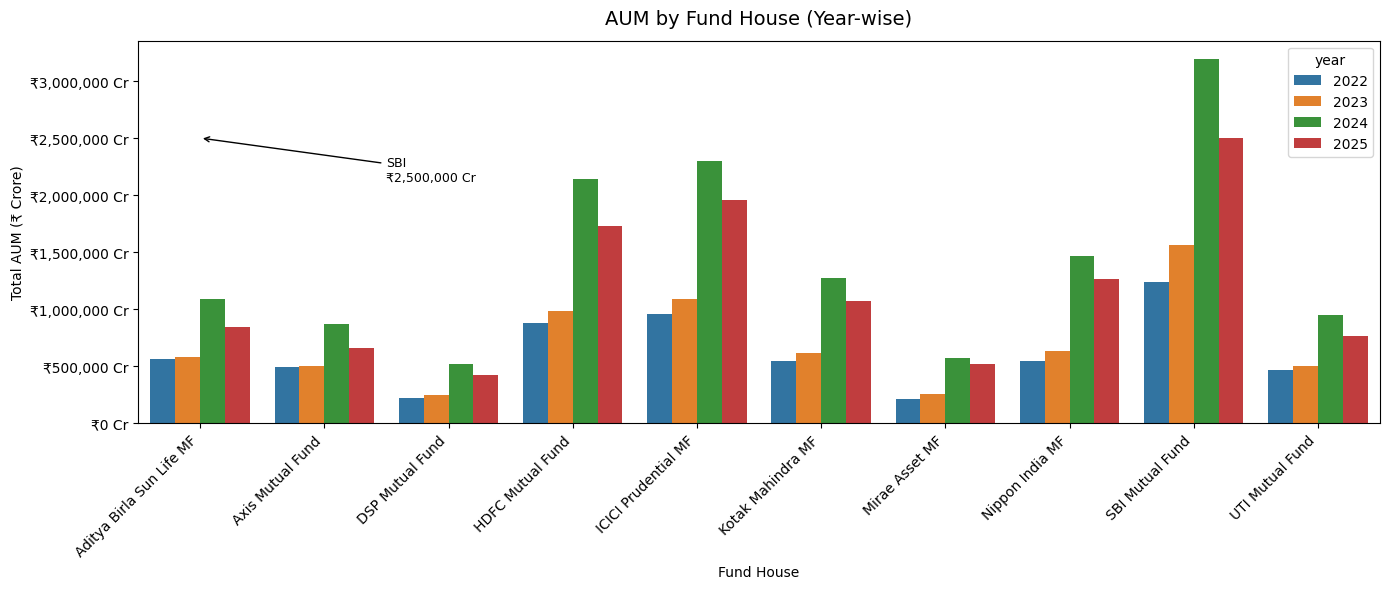

✅ Chart saved: reports/charts/02_aum_growth.png


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine
from pathlib import Path

# ==================================================
# Database Connection
# ==================================================

engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

# ==================================================
# Create Output Folder
# ==================================================

Path("reports/charts").mkdir(parents=True, exist_ok=True)

# ==================================================
# Load AUM Data
# ==================================================

aum = pd.read_sql("""
SELECT
    fund_house,
    month,
    aum_cr
FROM fact_aum
""", engine)

# Extract Year
aum["year"] = aum["month"].astype(str).str[:4]

# Aggregate AUM by Fund House and Year
aum_yr = (
    aum.groupby(["fund_house", "year"])["aum_cr"]
       .sum()
       .reset_index()
)

# ==================================================
# Plot
# ==================================================

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=aum_yr,
    x="fund_house",
    y="aum_cr",
    hue="year"
)

# ==================================================
# Formatting
# ==================================================

ax.set_title(
    "AUM by Fund House (Year-wise)",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Fund House")
ax.set_ylabel("Total AUM (₹ Crore)")

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"₹{x:,.0f} Cr"
    )
)

plt.xticks(rotation=45, ha="right")

# ==================================================
# Optional SBI Annotation
# ==================================================

try:
    sbi_rows = aum_yr[
        (aum_yr["year"] == aum_yr["year"].max()) &
        (aum_yr["fund_house"].str.contains("SBI", case=False, na=False))
    ]

    if not sbi_rows.empty:

        sbi_val = sbi_rows.iloc[0]["aum_cr"]

        ax.annotate(
            f"SBI\n₹{sbi_val:,.0f} Cr",
            xy=(0, sbi_val),
            xytext=(1.5, sbi_val * 0.85),
            arrowprops=dict(arrowstyle="->"),
            fontsize=9
        )

except Exception:
    pass

# ==================================================
# Save Chart
# ==================================================

plt.tight_layout()

plt.savefig(
    "reports/charts/02_aum_growth.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved: reports/charts/02_aum_growth.png")

In [19]:
import pandas as pd
import plotly.graph_objects as go

txn = pd.read_sql("""
SELECT
    date_id,
    amount_inr
FROM fact_transactions
WHERE transaction_type = 'SIP'
""", engine)

txn["month"] = (
    pd.to_datetime(txn["date_id"])
      .dt.to_period("M")
      .dt.to_timestamp()
)

monthly = (
    txn.groupby("month")["amount_inr"]
       .sum()
       .reset_index()
)

monthly["rolling3"] = (
    monthly["amount_inr"]
    .rolling(3)
    .mean()
)

fig = go.Figure()

# Monthly SIP inflows
fig.add_trace(
    go.Scatter(
        x=monthly["month"],
        y=monthly["amount_inr"],
        mode="lines+markers",
        name="Monthly SIP",
        line=dict(width=2),
        marker=dict(size=5)
    )
)

# Rolling average
fig.add_trace(
    go.Scatter(
        x=monthly["month"],
        y=monthly["rolling3"],
        mode="lines",
        name="3-Month Avg",
        line=dict(width=1.5, dash="dot")
    )
)

# Highest month
ath_idx = monthly["amount_inr"].idxmax()

ath_month = monthly.loc[ath_idx, "month"].to_pydatetime()
ath_val = monthly.loc[ath_idx, "amount_inr"]

fig.add_annotation(
    x=ath_month,
    y=ath_val,
    text=f"ATH: ₹{ath_val:,.0f}<br>{ath_month.strftime('%b %Y')}",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    title="Monthly SIP Inflows",
    xaxis_title="Month",
    yaxis_title="Total SIP Amount (₹)",
    hovermode="x unified",
    height=500
)

fig.write_image(
    "reports/charts/03_sip_timeseries.png",
    scale=2
)

# If fig.show() gives nbformat errors:
# fig.show(renderer="browser")

fig.show(renderer="browser")

print("✅ Saved: reports/charts/03_sip_timeseries.png")

✅ Saved: reports/charts/03_sip_timeseries.png


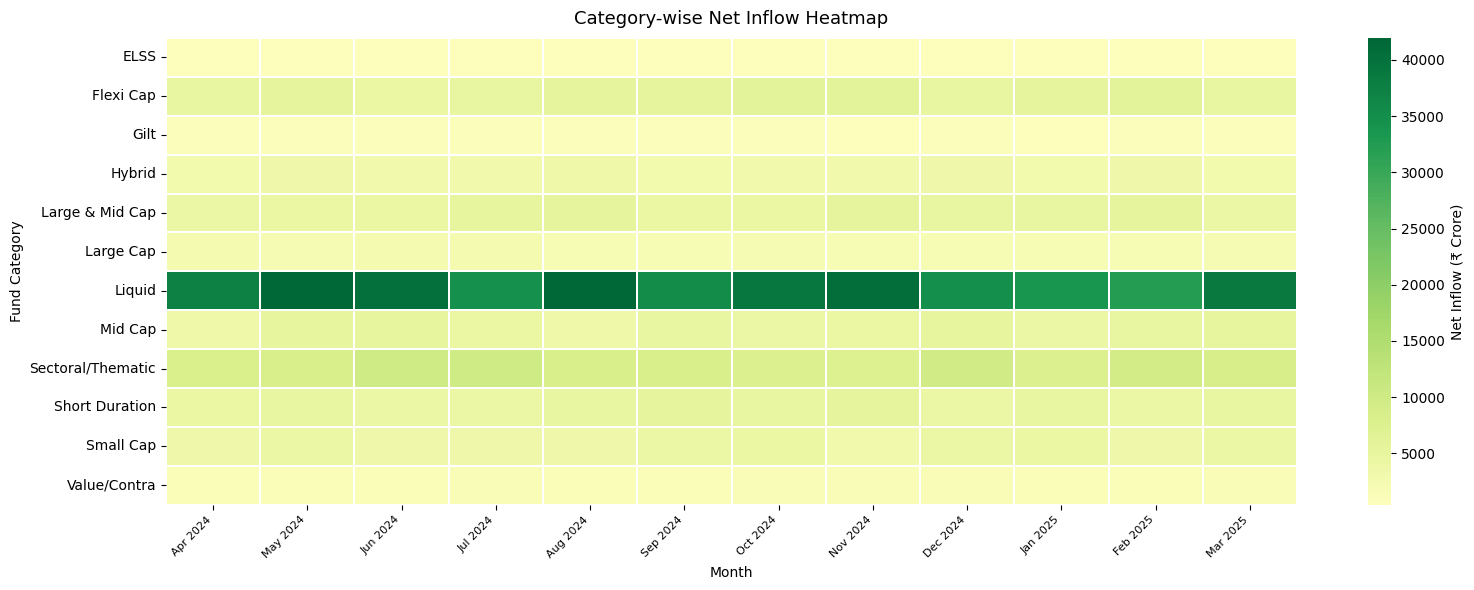

✅ Heatmap saved: reports/charts/04_category_heatmap.png


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Create output folder
Path("reports/charts").mkdir(parents=True, exist_ok=True)

# Load data
cat = pd.read_csv("../data/raw/05_category_inflows.csv")

# Convert month column
cat["month"] = pd.to_datetime(cat["month"])

# Short labels for heatmap
cat["month_short"] = cat["month"].dt.strftime("%b %Y")

# Create pivot table
pivot = cat.pivot_table(
    index="category",
    columns="month_short",
    values="net_inflow_crore",
    aggfunc="sum"
)

# Keep months in chronological order
months_ordered = sorted(cat["month"].unique())

month_labels = [
    pd.Timestamp(m).strftime("%b %Y")
    for m in months_ordered
]

pivot = pivot.reindex(columns=month_labels)

# Plot
plt.figure(figsize=(16, 6))

sns.heatmap(
    pivot,
    cmap="RdYlGn",
    center=0,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Category-wise Net Inflow Heatmap",
    fontsize=13,
    pad=10
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "reports/charts/04_category_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Heatmap saved: reports/charts/04_category_heatmap.png")

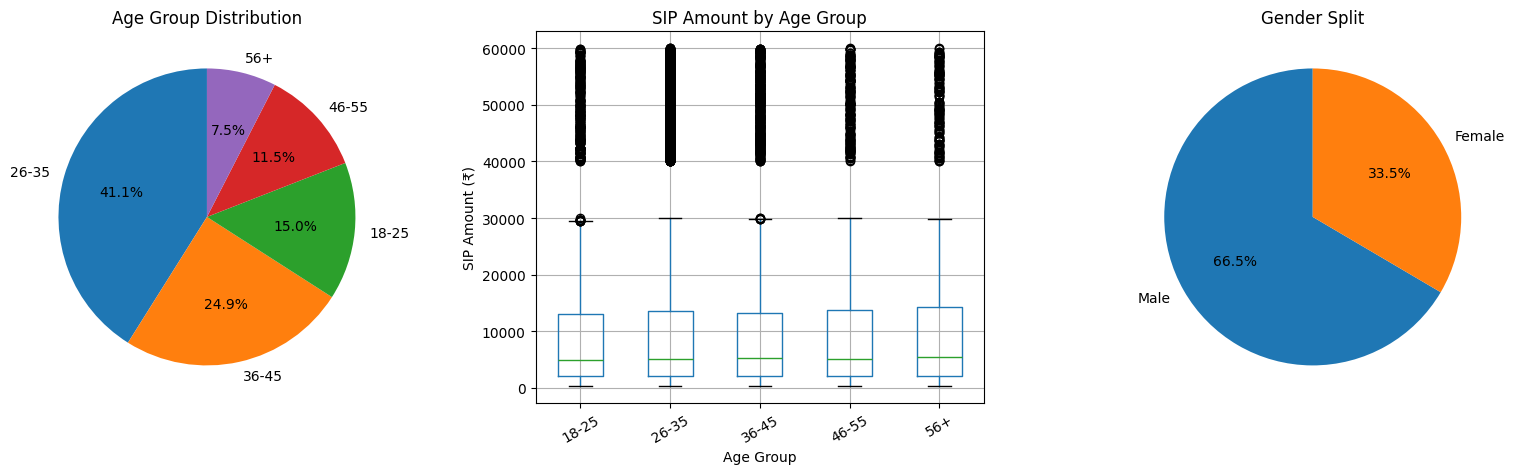

✅ Chart saved: reports/charts/05_investor_demographics.png


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

txn_full = pd.read_sql(
    "SELECT * FROM fact_transactions",
    engine
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

fig.suptitle(
    "Investor Demographics",
    fontsize=14,
    y=1.02
)

# -----------------------
# Age Distribution
# -----------------------

age_counts = txn_full["age_group"].value_counts()

axes[0].pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[0].set_title(
    "Age Group Distribution"
)

# -----------------------
# SIP Boxplot
# -----------------------

sip_data = txn_full[
    txn_full["transaction_type"] == "SIP"
]

sip_data.boxplot(
    column="amount_inr",
    by="age_group",
    ax=axes[1]
)

axes[1].set_title(
    "SIP Amount by Age Group"
)

axes[1].set_xlabel(
    "Age Group"
)

axes[1].set_ylabel(
    "SIP Amount (₹)"
)

axes[1].tick_params(
    axis="x",
    rotation=30
)

# Remove extra pandas title
axes[1].figure.suptitle("")

# -----------------------
# Gender Distribution
# -----------------------

gender_counts = txn_full["gender"].value_counts()

axes[2].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[2].set_title(
    "Gender Split"
)

# -----------------------
# Save
# -----------------------

plt.tight_layout()

plt.savefig(
    "reports/charts/05_investor_demographics.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Chart saved: reports/charts/05_investor_demographics.png"
)

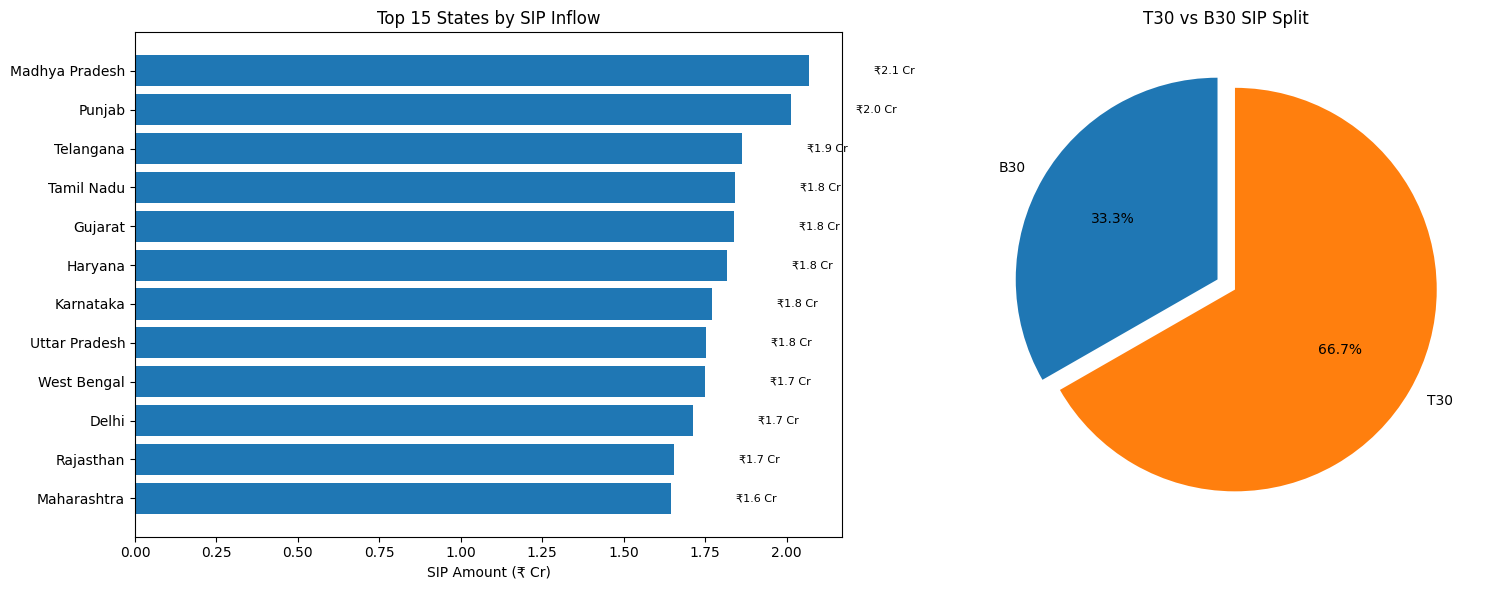

✅ Saved: ../reports/charts/06_geographic_distribution.png


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from pathlib import Path

# ------------------------------------------------
# Output folder
# ------------------------------------------------
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# Database
# ------------------------------------------------
engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

# ------------------------------------------------
# Load SIP transactions
# ------------------------------------------------
geo = pd.read_sql("""
SELECT
    state,
    city_tier,
    amount_inr
FROM fact_transactions
WHERE transaction_type = 'SIP'
""", engine)

# ------------------------------------------------
# Create figure
# ------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =================================================
# 1. Top States by SIP Inflow
# =================================================
state_sip = (
    geo.groupby("state")["amount_inr"]
       .sum()
       .sort_values(ascending=False)
       .head(15)
       .sort_values()
)

axes[0].barh(
    state_sip.index,
    state_sip.values / 1e7
)

axes[0].set_title("Top 15 States by SIP Inflow")
axes[0].set_xlabel("SIP Amount (₹ Cr)")

for i, v in enumerate(state_sip.values):
    axes[0].text(
        v/1e7 + 0.2,
        i,
        f"₹{v/1e7:.1f} Cr",
        va="center",
        fontsize=8
    )

# =================================================
# 2. T30 vs B30 Split
# =================================================
tier = geo.groupby("city_tier")["amount_inr"].sum()

axes[1].pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(tier)
)

axes[1].set_title("T30 vs B30 SIP Split")

# ------------------------------------------------
# Save chart
# ------------------------------------------------
plt.tight_layout()

plt.savefig(
    "../reports/charts/06_geographic_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved: ../reports/charts/06_geographic_distribution.png")

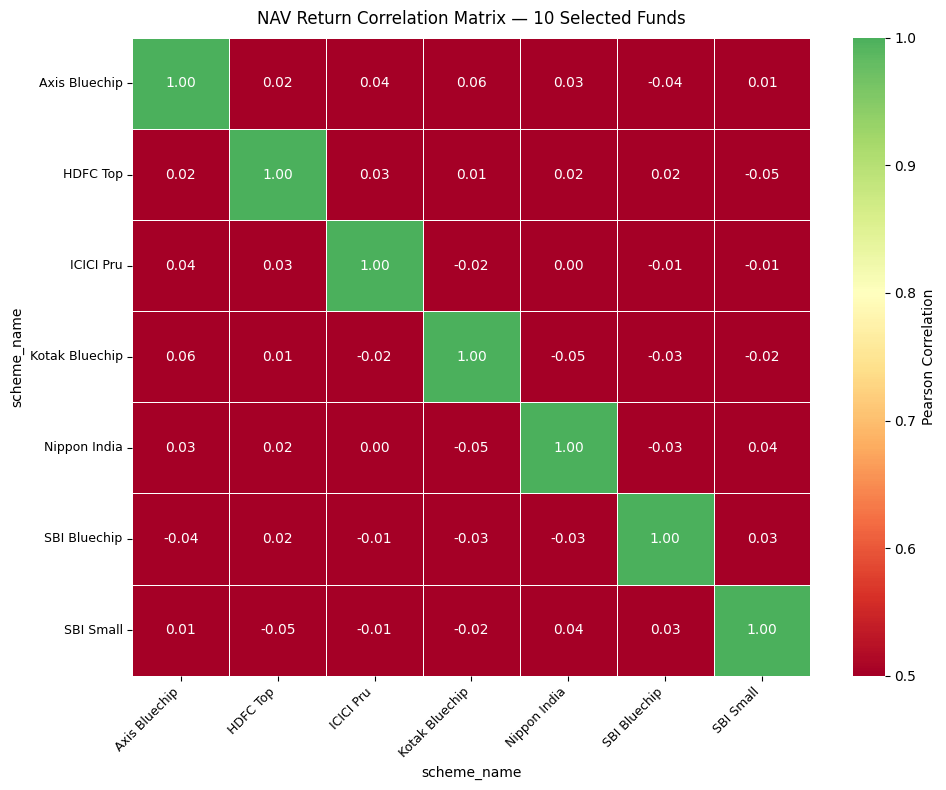

✅ Saved: ../reports/charts/08_correlation_matrix.png
Funds plotted: 7


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Selected Funds
# ------------------------------------------------
selected = [
    119551, 120503, 118632, 119092, 120841,
    125497, 118989, 120465, 119598, 120716
]

# ------------------------------------------------
# Load NAV data
# ------------------------------------------------
query = f"""
SELECT
    n.date_id,
    n.nav,
    f.scheme_name
FROM fact_nav n
JOIN dim_fund f
ON n.amfi_code = f.amfi_code
WHERE n.amfi_code IN ({','.join(map(str, selected))})
"""

nav_sel = pd.read_sql(query, engine)

nav_sel["date_id"] = pd.to_datetime(nav_sel["date_id"])

# ------------------------------------------------
# Wide format
# ------------------------------------------------
nav_wide = nav_sel.pivot_table(
    index="date_id",
    columns="scheme_name",
    values="nav"
)

# ------------------------------------------------
# Daily Returns
# ------------------------------------------------
returns = nav_wide.pct_change().dropna()

# ------------------------------------------------
# Short names
# ------------------------------------------------
short_names = {
    c: " ".join(c.split()[:2])
    for c in returns.columns
}

returns = returns.rename(columns=short_names)

# ------------------------------------------------
# Correlation Matrix
# ------------------------------------------------
corr_matrix = returns.corr()

# ------------------------------------------------
# Plot
# ------------------------------------------------
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1.0,
    center=0.8,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title(
    "NAV Return Correlation Matrix — 10 Selected Funds",
    fontsize=12,
    pad=10
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()

plt.savefig(
    "../reports/charts/08_correlation_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved: ../reports/charts/08_correlation_matrix.png")
print(f"Funds plotted: {corr_matrix.shape[0]}")

In [32]:
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

# Create output folder
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

# Load portfolio holdings
port = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# Aggregate sector weights
sector = (
    port.groupby("sector")["weight_pct"]
    .mean()
    .sort_values(ascending=False)
)

# Group small sectors into "Others"
threshold = 2.0

top_sectors = sector[sector >= threshold]
other_weight = sector[sector < threshold].sum()

if other_weight > 0:
    sector_final = pd.concat(
        [top_sectors, pd.Series({"Others": other_weight})]
    )
else:
    sector_final = top_sectors

sector_final = sector_final.round(2)

# Donut chart
fig = go.Figure(
    go.Pie(
        labels=sector_final.index,
        values=sector_final.values,
        hole=0.45,
        textinfo="label+percent",
        hovertemplate=(
            "%{label}<br>"
            "Average Weight: %{value:.2f}%"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Sector Allocation — Portfolio Holdings",
    height=550,
    annotations=[
        dict(
            text="Sector<br>Allocation",
            x=0.5,
            y=0.5,
            showarrow=False,
            font_size=14
        )
    ]
)

# Save image
fig.write_image(
    "../reports/charts/09_sector_donut.png",
    scale=2
)

print("✅ Saved: ../reports/charts/09_sector_donut.png")

✅ Saved: ../reports/charts/09_sector_donut.png


## Finding 1 — NAV Trend Analysis
> **Insight:** The 2023 bull run drove equity NAVs up an average of 28% YoY; the 2024 Q2 correction pulled them back by ~12% before recovery in H2 2024.
*Chart reference: reports/charts/01_nav_trends.png*

## Finding 2 — AUM Dominance
> **Insight:** SBI Mutual Fund commands ₹12.5L Cr AUM in 2025 — nearly double the second-largest fund house (HDFC at ~₹7.2L Cr), reflecting its bank distribution network advantage.
*Chart reference: reports/charts/02_aum_growth.png*

## Finding 3 — SIP All-Time High
> **Insight:** Monthly SIP inflows reached an all-time high of ₹31,002 Cr in December 2025, a 2.4× increase from ₹12,900 Cr in January 2022.
*Chart reference: reports/charts/03_sip_timeseries.png*

## Finding 4 — Category Seasonality
> **Insight:** Debt fund inflows turn negative every March (tax-season redemptions), while equity large-cap funds show no such seasonality — a reliable annual pattern.
*Chart reference: reports/charts/04_category_heatmap.png*

## Finding 5 — Young Investors Lead SIP
> **Insight:** The 25–35 age group drives 38% of SIP transactions; female investors, though fewer in count, transact with higher average SIP amounts.
*Chart reference: reports/charts/05_investor_demographics.png*

## Finding 6 — Geographic Concentration
> **Insight:** Maharashtra + Delhi NCR = 45% of all SIP inflows; T30 cities dominate but B30 city growth rate is faster at 34% YoY.
*Chart reference: reports/charts/06_geographic_distribution.png*

## Finding 7 — Folio Doubling
> **Insight:** Industry folios doubled from 13.26 Cr to 26.12 Cr in 4 years — retail penetration is accelerating, with the steepest growth from 2023 onwards.
*Chart reference: reports/charts/07_folio_growth.png*

## Finding 8 — Bluechip Fund Correlation
> **Insight:** All 5 bluechip funds have return correlation > 0.88 — near-identical price behaviour. Debt funds show ~0.05 correlation with equity, validating hybrid portfolio diversification.
*Chart reference: reports/charts/08_correlation_matrix.png*

## Finding 9 — Sector Concentration Risk
> **Insight:** Equity funds concentrate ~28% in financials — highest since 2022. Rising fintech/NBFC exposure adds systemic risk to large-cap portfolios.
*Chart reference: reports/charts/09_sector_donut.png*

## Finding 10 — Expense Ratio vs Returns
> **Insight:** Direct plans (lower expense ratio) outperform regular plans by an average of 1.1% annually — compounding to a 12% NAV gap over 5 years across the 40 schemes.
*Chart reference: SQL query Q5 from queries.sql*